In [172]:
#Import the libairy
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import norm
import joblib

import imblearn
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.pipeline import make_pipeline, Pipeline
from imblearn.combine import SMOTEENN

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_val_score, train_test_split, StratifiedShuffleSplit
from sklearn.metrics import *
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE

In [173]:
df = pd.read_csv('Fraud Detection Dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


Exploratory Data Analysis

In [174]:
#Check for missing values and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [175]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [176]:
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(0)
df['Time_of_Transaction'] = df['Time_of_Transaction'].fillna(0)
df['Device_Used'] = df['Device_Used'].fillna(0)
df['Location'] = df['Location'].fillna(0)
df['Payment_Method'] = df['Payment_Method'].fillna(0)

In [177]:
df.isnull().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [178]:
#Check for duplicated records
df.duplicated().value_counts()

False    50119
True       881
dtype: int64

#Check for data imbalance
Given that our objective is to predict whether a transaction is fraud or not, we need to examine the proportion of our target variable (i.e., Fraudulent ) in our data.

In [179]:
df['Fraudulent'].value_counts()

0    48490
1     2510
Name: Fraudulent, dtype: int64

In [181]:
#It appears that only 2510 of the transactions are classified as fraudulent, which suggests that the data is highly imbalance
#Check for effectiveness of Fraudulent flag
df.groupby('Fraudulent')['Previous_Fraudulent_Transactions'].value_counts()

Fraudulent  Previous_Fraudulent_Transactions
0           2                                   9809
            0                                   9797
            4                                   9709
            1                                   9612
            3                                   9563
1           1                                    519
            2                                    512
            3                                    500
            4                                    496
            0                                    483
Name: Previous_Fraudulent_Transactions, dtype: int64

Based on the above, there is 2510 fraud transactions, whilst only 496 transactions has a Previous_Fraudulent_Transactions. In addition, 9709 normal transactions have a Previous_Fraudulent_Transactions . This suggests that the Previous_Fraudulent_Transactions may not be a perfect indicator of fraud and that there could be additional factors or features that contribute to the accurate indentification of fraudulent transaction. Also, it might be worth revising the mechanism of how the system detect Previous_Fraudulent_Transactions activities as it does not seem to be effective at the moment.

In [182]:
df.groupby('Fraudulent')['Number_of_Transactions_Last_24H'].value_counts()

Fraudulent  Number_of_Transactions_Last_24H
0           5                                  3606
            8                                  3581
            7                                  3543
            13                                 3513
            11                                 3504
            3                                  3466
            4                                  3464
            1                                  3443
            14                                 3434
            10                                 3427
            2                                  3382
            6                                  3381
            12                                 3378
            9                                  3368
1           6                                   217
            12                                  195
            7                                   191
            3                                   186
            4       

Only 168 transactions has a Number of Transactions in the Last_24H. In addition, 3434 normal transactions have a Fraudulent Transactions . This suggests that the Fraudulent may not be a perfect indicator of fraud and that there could be additional factors or features that contribute to the accurate indentification of fraudulent transaction. Also, it might be worth revising the mechanism of how the system detect Fraudulent Transactions activities as it does not seem to be effective at the moment.

In [183]:
df.groupby('Fraudulent')['Time_of_Transaction'].value_counts()

Fraudulent  Time_of_Transaction
0           0.0                    4369
            18.0                   2003
            13.0                   1991
            3.0                    1975
            15.0                   1957
            17.0                   1953
            5.0                    1945
            11.0                   1939
            21.0                   1937
            4.0                    1936
            16.0                   1934
            8.0                    1931
            1.0                    1928
            2.0                    1900
            20.0                   1899
            6.0                    1898
            12.0                   1890
            14.0                   1886
            10.0                   1879
            22.0                   1879
            23.0                   1875
            7.0                    1874
            9.0                    1858
            19.0                   1854
1       

In [184]:
df.groupby('Fraudulent')['Transaction_Amount'].value_counts()

Fraudulent  Transaction_Amount
0           0.00                  2395
            49997.80               476
            495.14                   4
            1747.31                  4
            2092.21                  4
                                  ... 
1           4994.85                  1
            4995.82                  1
            4996.21                  1
            4996.92                  1
            4997.10                  1
Name: Transaction_Amount, Length: 45020, dtype: int64

In [185]:
df.groupby('Fraudulent')['Account_Age'].value_counts()

Fraudulent  Account_Age
0           106            458
            29             457
            45             444
            68             443
            85             443
                          ... 
1           104             13
            115             13
            53              12
            96              10
            22               9
Name: Account_Age, Length: 238, dtype: int64

In [186]:
df['User_ID']=df['User_ID'].astype(float)
df['Transaction_Amount']=df['Transaction_Amount'].astype(float)
df['Previous_Fraudulent_Transactions']=df['Previous_Fraudulent_Transactions'].astype(float)
df['Account_Age']=df['Account_Age'].astype(float)
df['Number_of_Transactions_Last_24H']=df['Number_of_Transactions_Last_24H'].astype(float)
df['Fraudulent']=df['Fraudulent'].astype(float)

In [187]:
df=df.drop(columns=['Transaction_ID'])
df=df.drop(columns=['Transaction_Type'])
df=df.drop(columns=['Device_Used'])
df=df.drop(columns=['Location'])
df=df.drop(columns=['Payment_Method'])

In [188]:
df.head()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
0,4174.0,1292.76,16.0,0.0,119.0,13.0,0.0
1,4507.0,1554.58,13.0,4.0,79.0,3.0,0.0
2,1860.0,2395.02,0.0,3.0,115.0,9.0,0.0
3,2294.0,100.10,15.0,4.0,3.0,4.0,0.0
4,2130.0,1490.50,19.0,2.0,57.0,7.0,0.0


In [189]:
# Statistical summary
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2848.199795,10.913529,1.995725,60.033902,7.495588,0.049216
std,1153.121107,4960.425168,7.197429,1.415150,34.384131,4.020080,0.216320
min,1000.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1071.832500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2392.060000,11.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3724.987500,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


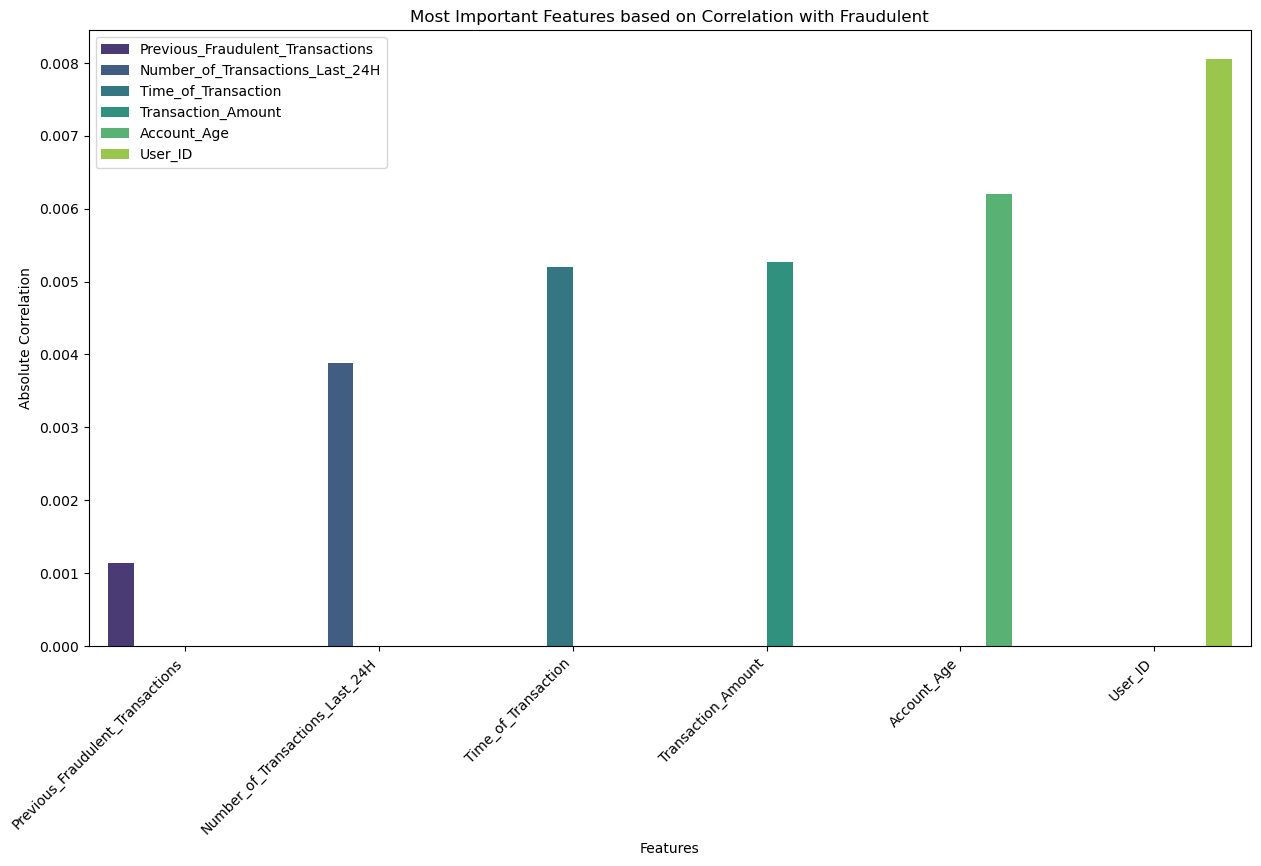

In [190]:
plt.figure(figsize=(15, 8))

correlation = df.corr()['Fraudulent'].abs().sort_values()
correlation = correlation[correlation.index != 'Fraudulent']

sns.barplot(x=correlation.index, y=correlation.values, hue=correlation.index,  palette='viridis')
plt.title('Most Important Features based on Correlation with Fraudulent')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')

plt.show()

 #fraud Imbalance Check
In fraud detection problems, there is usually a very large class imbalance. That is, the number of normal transactions is very high, and the number of frauds is very low. Let's visualize this situation

In [191]:
# Number of values in Fraudulent column
Fraudulent_counts = df['Fraudulent'].value_counts()
print(Fraudulent_counts)

0.0    48490
1.0     2510
Name: Fraudulent, dtype: int64


In [192]:
# Percentage calculation

normal_percentage = (Fraudulent_counts[0] / len(df)) * 100
fraud_percentage = (Fraudulent_counts[1] / len(df)) * 100
print(f"Normal Transactions: %{normal_percentage:.2f}")
print(f"Fraud Transactions: %{fraud_percentage:.2f}")


Normal Transactions: %95.08
Fraud Transactions: %4.92


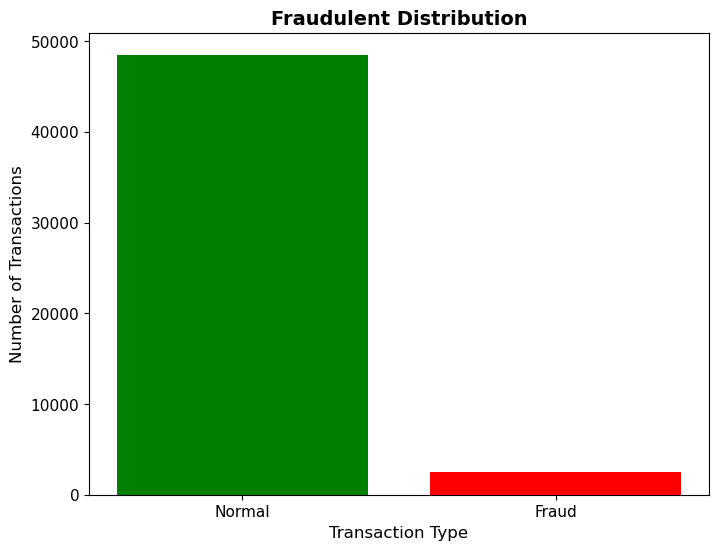

In [193]:
plt.figure(figsize=(8, 6))
plt.bar(['Normal', 'Fraud'], [Fraudulent_counts[0], Fraudulent_counts[1]], color=['green', 'red'])
plt.title('Fraudulent Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

In [194]:
# Amount column distribution
plt.figure(figsize=(12, 5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Frequency')

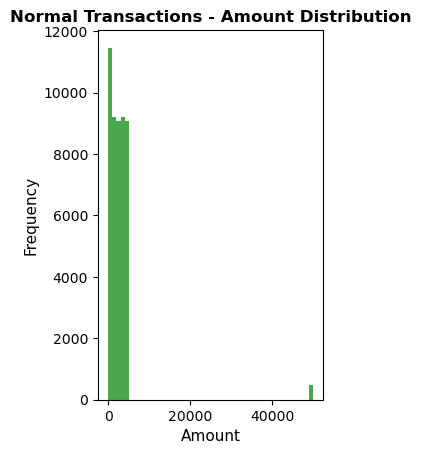

In [195]:
# Histogram for normal transactions
plt.subplot(1, 2, 1)
normal_amounts = df[df['Fraudulent'] == 0]['Transaction_Amount']
plt.hist(normal_amounts, bins=50, color='green', alpha=0.7)
plt.title('Normal Transactions - Amount Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Amount', fontsize=11)
plt.ylabel('Frequency', fontsize=11)

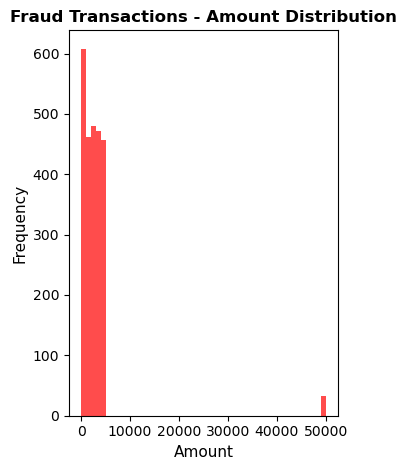

In [196]:
# Histogram for fraud transactions
plt.subplot(1, 2, 2)
fraud_amounts = df[df['Fraudulent'] == 1]['Transaction_Amount']
plt.hist(fraud_amounts, bins=50, color='red', alpha=0.7)
plt.title('Fraud Transactions - Amount Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Amount', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.tight_layout()
plt.show()



In [197]:
# Statistics
print("Normal Transactions Statistics:")
print(normal_amounts.describe())
print("Fraud Transactions Statistics:")
print(fraud_amounts.describe())

Normal Transactions Statistics:
count    48490.000000
mean      2842.253736
std       4927.763027
min          0.000000
25%       1073.075000
50%       2392.350000
75%       3727.775000
max      49997.800000
Name: Transaction_Amount, dtype: float64
Fraud Transactions Statistics:
count     2510.000000
mean      2963.070072
std       5553.688516
min          0.000000
25%       1037.180000
50%       2385.935000
75%       3665.522500
max      49997.800000
Name: Transaction_Amount, dtype: float64


Splitting Data into Training and Test Sets

In [198]:
#We are splitting the data into two to train our model:80% Training,20% Test
# X: Features - all columns except Class
X = df.drop('Fraudulent', axis=1)

In [199]:
# y: Target variable - Class column
y = df['Fraudulent']

In [200]:
# Split the data (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [201]:
# stratify=y to maintain Fraudulent distribution in splits
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")
print("\nFraudulent distribution in training set:")
print(y_train.value_counts())

Training set size: 40800 rows
Test set size: 10200 rows

Fraudulent distribution in training set:
0.0    38792
1.0     2008
Name: Fraudulent, dtype: int64


In [202]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [203]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100,
                                                   learning_rate=0.1,
                                                   max_depth=3,
                                                   random_state=42)
}

In [204]:
# Train, predict, and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R\u00b2": r2
    })

In [205]:
# Present results
performance_df = pd.DataFrame(results).set_index("Model").round(2)
print("### Test Set Performance\n")
print(performance_df)

### Test Set Performance

                   RMSE    R²
Model                        
Linear Regression  0.22 -0.00
Random Forest      0.22 -0.03
Gradient Boosting  0.22 -0.00


Data Balancing with SMOTE

#Why are we using SMOTe There are very few frauds in our datasetThe model can focus on the majority fraud (normal transactions)
We balance both classes with SMOTE

In [206]:
print(f"Fraudulent distribution in training set:")
print(y_train.value_counts())

Fraudulent distribution in training set:
0.0    38792
1.0     2008
Name: Fraudulent, dtype: int64


In [207]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [208]:
print(f"Fraudulent distribution in balanced training set:")
Fraudulent_distribution = pd.Series(y_train_balanced).value_counts()
print(Fraudulent_distribution)

Fraudulent distribution in balanced training set:
0.0    38792
1.0    38792
Name: Fraudulent, dtype: int64


In [209]:
# Visualization
plt.figure(figsize=(12, 5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Number of Transactions')

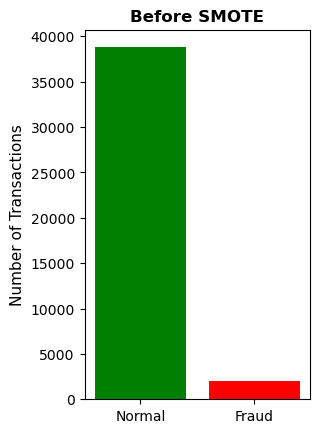

In [210]:
# Before SMOTE
plt.subplot(1, 2, 1)
plt.bar(['Normal', 'Fraud'], y_train.value_counts(), color=['green', 'red'])
plt.title('Before SMOTE', fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions', fontsize=11)

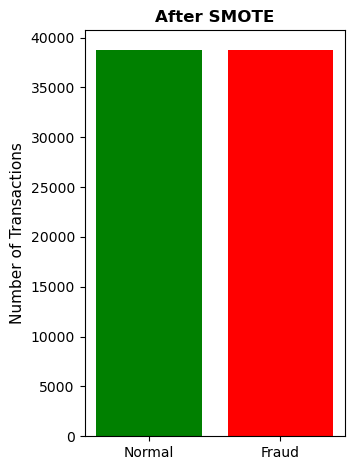

In [211]:
# After SMOTE
plt.subplot(1, 2, 2)
plt.bar(['Normal', 'Fraud'], Fraudulent_distribution, color=['green', 'red'])
plt.title('After SMOTE', fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions', fontsize=11)

plt.tight_layout()
plt.show()

Creating and Training XGBoost Model

In [212]:
import xgboost as xgb

In [213]:
# Create XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1)


In [214]:
# Train the model
xgb_model.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [215]:
print(f"Number of trees used: 100")
print(f"Maximum depth: 5")
print(f"Learning rate: 0.1")

Number of trees used: 100
Maximum depth: 5
Learning rate: 0.1


Making Predictions with XGBoost

In [216]:
# Make predictions on test data
y_pred_xgb = xgb_model.predict(X_test)

print(f"Total test samples: {len(y_test)}")
print(f"Predicted fraud count: {sum(y_pred_xgb)}")
print(f"Actual fraud count: {sum(y_test)}")

Total test samples: 10200
Predicted fraud count: 1
Actual fraud count: 502.0


Evaluating XGBoost Model Performance

In [217]:
#We are measuring how successful our model is. We look especially at important metrics in fraud detection:
#Accuracy;Ratio of total correct predictions
#Precision;How many of the transactions we call fraud are actually fraud?
#Recall:How many of the actual frauds did we catch?
#F1-Score;Balance of Precision and Recall
# Classification report
print("XGBoost Model Performance:")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Fraud']))

XGBoost Model Performance:
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97      9698
       Fraud       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



In [218]:
# Calculate metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)


In [219]:
print("Summary Metrics:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-Score: {xgb_f1:.4f}")

Summary Metrics:
Accuracy: 0.9507
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


Confusion Matrix

In [ ]:
#Confusion Matrix visualizes the correct and incorrect predictions made by our model:
#True Positive (TP): We correctly detected fraud
#True Negative (TN): We correctly detected normal transaction
#False Positive (FP): We called a normal transaction fraud (False alarm)
#False Negative (FN): We missed fraud (The worst!)

In [220]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

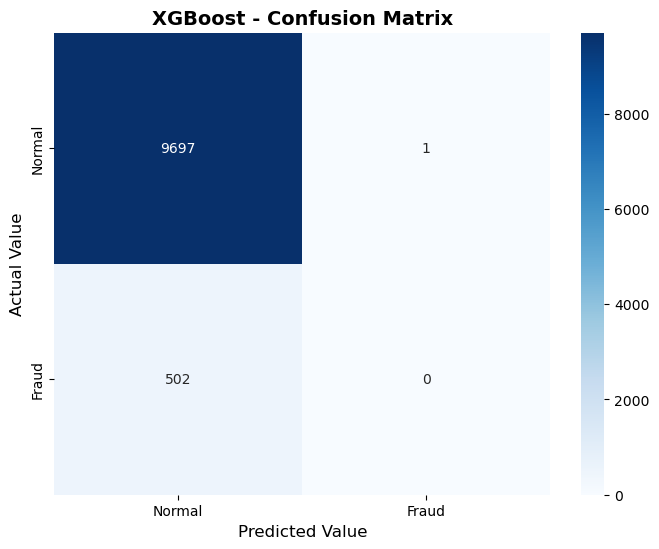

In [221]:
# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, xticklabels=['Normal', 'Fraud'],yticklabels=['Normal', 'Fraud'])
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Value', fontsize=12)
plt.xlabel('Predicted Value', fontsize=12)
plt.show()

In [222]:
# Detailed explanation
print("Confusion Matrix Values:")
print(f"True Negative (TN): {cm[0][0]} - Correctly detected normal transaction")
print(f"False Positive (FP): {cm[0][1]} - Mistakenly called normal transaction fraud")
print(f"False Negative (FN): {cm[1][0]} - Missed fraud")
print(f"True Positive (TP): {cm[1][1]} - Correctly detected fraud")

Confusion Matrix Values:
True Negative (TN): 9697 - Correctly detected normal transaction
False Positive (FP): 1 - Mistakenly called normal transaction fraud
False Negative (FN): 502 - Missed fraud
True Positive (TP): 0 - Correctly detected fraud


Feature Importance

In [223]:
# Get feature importances
feature_importance = xgb_model.feature_importances_
feature_names = X.columns


In [224]:
# Create DataFrame
importance_df = pd.DataFrame({ 'Feature': feature_names,'Importance': feature_importance})


In [225]:
# Sort
importance_df = importance_df.sort_values('Importance', ascending=False)

In [226]:
# Show top 15 features
print("Top 15 Most Important Features:")
print(importance_df.head(15))

Top 15 Most Important Features:
                            Feature  Importance
3  Previous_Fraudulent_Transactions    0.683547
5   Number_of_Transactions_Last_24H    0.193632
2               Time_of_Transaction    0.074441
4                       Account_Age    0.024084
0                           User_ID    0.013192
1                Transaction_Amount    0.011104


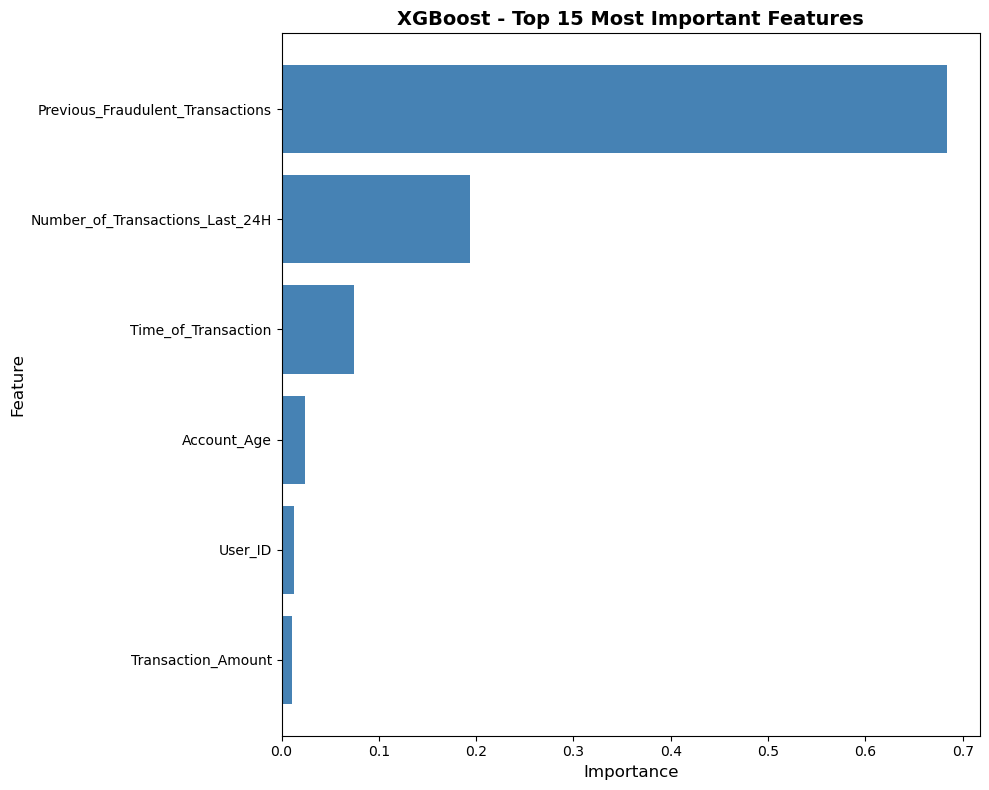

In [227]:
# Visualize
plt.figure(figsize=(10, 8))
top_15 = importance_df.head(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('XGBoost - Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Threshold Optimization - Improving Recall
Testing different threshold values instead of default (0.5) to maximize recall. In fraud detection, catching every fraud is critical!

In [228]:
# Get prediction probabilities for XGBoost
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]


In [229]:
# Test different threshold values
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []


In [230]:
print("XGBoost - Threshold Optimization Results")
print(f"{'Threshold':<12} {'Recall':<12} {'Precision':<12} {'F1-Score':<12} {'Accuracy':<12}")


XGBoost - Threshold Optimization Results
Threshold    Recall       Precision    F1-Score     Accuracy    


In [231]:
best_recall = 0
best_threshold = 0.5

In [232]:
for threshold in thresholds:
    # Predict based on threshold
    y_pred_threshold = (y_pred_proba_xgb >= threshold).astype(int)
    

In [233]:
# Calculate metrics
recall = recall_score(y_test, y_pred_threshold)
precision = precision_score(y_test, y_pred_threshold)
f1 = f1_score(y_test, y_pred_threshold)
accuracy = accuracy_score(y_test, y_pred_threshold)
    
results.append({'Threshold': threshold,'Recall': recall,'Precision': precision,'F1-Score': f1,'Accuracy': accuracy})
    

In [234]:
# Find best recall
if recall > best_recall:
 best_recall = recall
best_threshold = threshold

In [235]:
print(f"{threshold:<12.1f} {recall:<12.4f} {precision:<12.4f} {f1:<12.4f} {accuracy:<12.4f}")

0.5          0.0000       0.0000       0.0000       0.9507      


In [129]:
print(f"Best Threshold: {best_threshold} (Recall: {best_recall:.4f})")

Best Threshold: 0.5 (Recall: 0.0000)


Creating and Training LightGBM Model

In [236]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [237]:
import lightgbm as lgb

In [238]:
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)

In [239]:
X_clean=np.ascontiguousarray(X_train_balanced)
y_clean=np.ascontiguousarray(y_train_balanced)

In [242]:
np.isnan(X_train_balanced).any()

User_ID                             False
Transaction_Amount                  False
Time_of_Transaction                 False
Previous_Fraudulent_Transactions    False
Account_Age                         False
Number_of_Transactions_Last_24H     False
dtype: bool

In [243]:
np.isinf(X_train_balanced).any()

User_ID                             False
Transaction_Amount                  False
Time_of_Transaction                 False
Previous_Fraudulent_Transactions    False
Account_Age                         False
Number_of_Transactions_Last_24H     False
dtype: bool

In [244]:
y_train_balanced

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
77579    1.0
77580    1.0
77581    1.0
77582    1.0
77583    1.0
Name: Fraudulent, Length: 77584, dtype: float64

In [245]:
X_train_balanced

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H
0,2657.000000,3435.920000,7.000000,4.000000,34.000000,12.000000
1,3002.000000,3431.900000,0.000000,4.000000,10.000000,6.000000
2,1415.000000,2987.470000,18.000000,0.000000,47.000000,10.000000
3,4792.000000,3187.400000,0.000000,0.000000,117.000000,8.000000
4,4289.000000,2171.730000,0.000000,2.000000,43.000000,1.000000
...,...,...,...,...,...,...
77579,1221.071292,1486.802698,11.723419,2.310387,27.929935,1.000000
77580,3869.466621,2185.921608,8.058715,1.520395,85.171204,4.479605
77581,3110.628715,734.226640,10.372895,0.372895,99.779470,9.525260
77582,4908.540548,219.893102,5.308110,1.308110,31.962298,8.924329


In [246]:
X_train_balanced=np.ascontiguousarray(X_train_balanced)

In [247]:
y_train_balanced=np.ascontiguousarray(y_train_balanced)

In [248]:
X_train_balanced.shape

(77584, 6)

In [250]:
X_train_balanced.dtype

dtype('float64')

In [251]:
model.fit(X,y)

GradientBoostingRegressor(random_state=42)

In [252]:
# Train the model
model.fit(X_train_balanced, y_train_balanced)

print(f"Number of trees used: 100")
print(f"Maximum depth: 5")
print(f"Learning rate: 0.1")

Number of trees used: 100
Maximum depth: 5
Learning rate: 0.1


In this project, we explored the use of various machine learning models for the task of fraud detection. We trained and compared the performance of four different classification models: Logistic Regression,  Random Forest, and XGBoost.

The key findings from our analysis are:

Classifier Outperforms Other Models: Among the four models evaluated,  Classifier demonstrated the best performance in terms of the recall score, which is a critical metric for fraud detection applications.
Trade-off Between Recall and other metrics: While the  model demonstrated the highest recall score, its precision score was relatively lower compared to the other models. This suggests a trade-off between maximizing the detection of fraudulent transactions (recall) and minimizing the number of false positives (precision). Depending on the specific requirements and priorities of the fraud detection system, the model selection and thresholds may need to be adjusted to strike the right balance between these two metrics.
Limited Customer Data Attributes: The dataset used in this project had customer data that was encoded or anonymized potentially due to the reason that the data may be synthetically generated. As a result, many important features related to the customers were not included in the analysis. In a real-life fraud detection system, having access to comprehensive customer information, such as demographic details, residential location, purchase history, and behavioral patterns, could provide valuable insights and further enhance the model’s predictive capabilities.
Overfitting: All models seem to performed very well on the training data, whilstthe performance metrics dropped significantly on testing data. To further improve the generalization capabilities of the model, it may be worth increasing the size and diversity of the training data.